# Image dataset EDA

Explore image quality, split balance, and YOLO bounding-box annotations for the Vietnam traffic-sign dataset. The notebook locates `data/raw/vnts/data.yaml` from the current working directory or one of its parents. The dataset YAML's class names are used, while split folders are read directly from the dataset directory so the notebook works with this repository's `train/`, `valid/`, and `test/` layout.

All summaries are calculated from files currently present; no dataset counts are hardcoded.

In [1]:
from pathlib import Path
from collections import Counter
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image, ImageDraw

%matplotlib inline

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}
SPLIT_NAMES = ('train', 'valid', 'test')

# Search the current folder and its parents, including when launched in src/eda.
DATASET_CONFIG = next(
    (parent / 'data' / 'raw' / 'vnts' / 'data.yaml'
     for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / 'data' / 'raw' / 'vnts' / 'data.yaml').is_file()),
    None,
)
if DATASET_CONFIG is None:
    raise FileNotFoundError(
        'Could not find data/raw/vnts/data.yaml. Run this notebook from the repository root or a subfolder.'
    )

DATASET_ROOT = DATASET_CONFIG.parent
with DATASET_CONFIG.open(encoding='utf-8') as file:
    dataset_config = yaml.safe_load(file) or {}

raw_names = dataset_config.get('names', {})
if isinstance(raw_names, list):
    CLASS_NAMES = {index: str(name) for index, name in enumerate(raw_names)}
elif isinstance(raw_names, dict):
    CLASS_NAMES = {int(index): str(name) for index, name in raw_names.items()}
else:
    CLASS_NAMES = {}

SPLIT_DIRS = {
    split: (DATASET_ROOT / split / 'images', DATASET_ROOT / split / 'labels')
    for split in SPLIT_NAMES
}
print(f'Dataset: {DATASET_ROOT}')
print(f'Classes in YAML: {len(CLASS_NAMES)}')
for split, (images_dir, labels_dir) in SPLIT_DIRS.items():
    print(f'{split:>5}: images={images_dir.is_dir()}, labels={labels_dir.is_dir()}')

Dataset: /home/dangle/code/VNTS-recognition/data/raw/vnts
Classes in YAML: 58
train: images=True, labels=True
valid: images=True, labels=True
 test: images=True, labels=True


## Split inventory and image-label pairing

Count supported image files by split, identify missing corresponding label files, and collect image dimensions and file sizes. Corrupt/unreadable images are recorded instead of stopping the analysis.

In [2]:
inventory_rows = []
image_rows = []

for split, (images_dir, labels_dir) in SPLIT_DIRS.items():
    image_paths = sorted(
        path for path in images_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ) if images_dir.is_dir() else []
    label_paths = {path.stem: path for path in labels_dir.glob('*.txt')} if labels_dir.is_dir() else {}
    image_stems = {path.stem for path in image_paths}
    missing_labels = sorted(image_stems - label_paths.keys())
    orphan_labels = sorted(label_paths.keys() - image_stems)
    inventory_rows.append({
        'split': split,
        'images': len(image_paths),
        'label_files': len(label_paths),
        'images_missing_labels': len(missing_labels),
        'orphan_label_files': len(orphan_labels),
    })

    for image_path in image_paths:
        row = {
            'split': split,
            'image': image_path,
            'label': label_paths.get(image_path.stem),
            'format': image_path.suffix.lower().lstrip('.'),
            'file_size_kb': image_path.stat().st_size / 1024,
            'width': np.nan,
            'height': np.nan,
            'mode': None,
            'read_error': None,
        }
        try:
            with Image.open(image_path) as image:
                row.update(width=image.width, height=image.height, mode=image.mode)
                image.verify()
        except Exception as error:
            row['read_error'] = str(error)
        image_rows.append(row)

inventory = pd.DataFrame(inventory_rows).set_index('split')
image_df = pd.DataFrame(image_rows)
display(inventory)
print(f'Total images: {len(image_df):,}')
print(f'Unreadable images: {image_df.read_error.notna().sum():,}')
if not image_df.empty:
    display(image_df.groupby('split')[['width', 'height', 'file_size_kb']].agg(['count', 'mean', 'min', 'max']).round(2))
    display(image_df.groupby(['split', 'format']).size().rename('count').to_frame())

,images,label_files,images_missing_labels,orphan_label_files
split,,,,
train,9536,9536,0,0
valid,784,784,0,0
test,613,613,0,0


Total images: 10,933
Unreadable images: 0


width                  height                  file_size_kb         \
      count   mean  min  max  count   mean  min  max        count   mean   
split                                                                      
test    613  640.0  640  640    613  640.0  640  640          613  72.31   
train  9536  640.0  640  640   9536  640.0  640  640         9536  74.73   
valid   784  640.0  640  640    784  640.0  640  640          784  73.15   

                      
         min     max  
split                 
test   10.69  124.72  
train  11.11  126.70  
valid  11.19  117.03

,,count
split,format,
test,jpg,613
train,jpg,9536
valid,jpg,784


## Image dimensions and file sizes

Visualize image width and height distributions and compare file sizes across splits. This can reveal inconsistent preprocessing or unexpected image files.

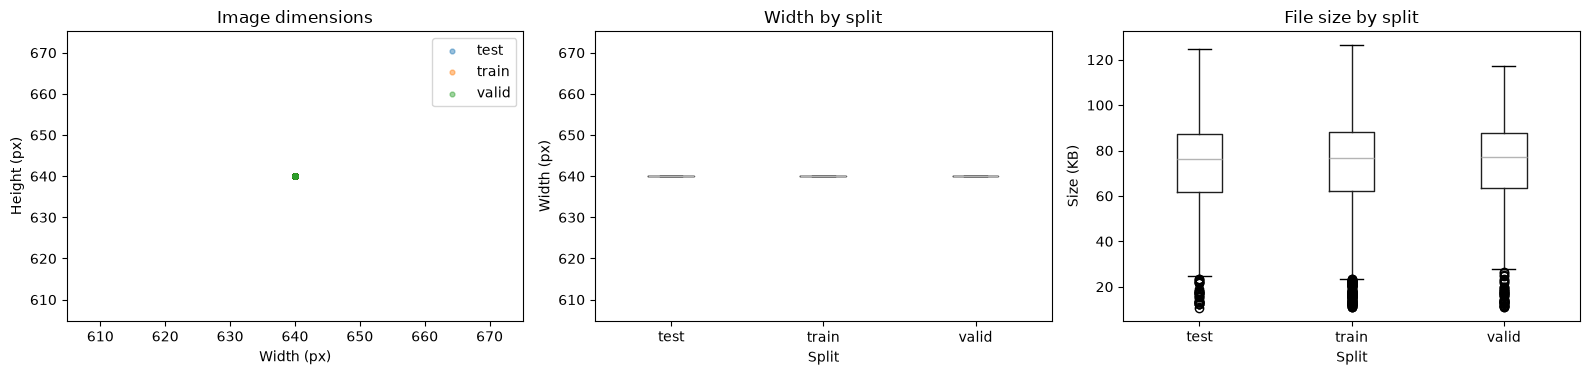

In [3]:
valid_images = image_df.dropna(subset=['width', 'height']).copy()
if valid_images.empty:
    print('No readable images were found.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for split, group in valid_images.groupby('split'):
        axes[0].scatter(group['width'], group['height'], s=12, alpha=0.45, label=split)
    axes[0].set(title='Image dimensions', xlabel='Width (px)', ylabel='Height (px)')
    axes[0].legend()
    valid_images.boxplot(column='width', by='split', ax=axes[1], grid=False)
    axes[1].set(title='Width by split', xlabel='Split', ylabel='Width (px)')
    valid_images.boxplot(column='file_size_kb', by='split', ax=axes[2], grid=False)
    axes[2].set(title='File size by split', xlabel='Split', ylabel='Size (KB)')
    fig.suptitle('')
    plt.tight_layout()
    plt.show()

## YOLO annotation quality and class balance

Each non-empty YOLO row should contain `class_id x_center y_center width height`, with normalized coordinates in $[0, 1]$. The parser reports malformed rows, invalid class IDs, and out-of-range boxes, then summarizes object and per-image counts.

In [4]:
annotation_rows = []
annotation_issues = []
per_image_rows = []

for row in image_rows:
    label_path = row['label']
    object_count = 0
    if label_path is not None:
        try:
            lines = label_path.read_text(encoding='utf-8').splitlines()
        except OSError as error:
            annotation_issues.append({'file': str(label_path), 'line': None, 'issue': f'Could not read: {error}'})
            lines = []
        for line_number, line in enumerate(lines, start=1):
            if not line.strip():
                continue
            parts = line.split()
            try:
                if len(parts) != 5:
                    raise ValueError(f'expected 5 values, found {len(parts)}')
                class_id = int(parts[0])
                x_center, y_center, box_width, box_height = map(float, parts[1:])
                if class_id < 0 or (CLASS_NAMES and class_id not in CLASS_NAMES):
                    raise ValueError(f'class id {class_id} is not defined in data.yaml')
                if not all(np.isfinite(value) for value in (x_center, y_center, box_width, box_height)):
                    raise ValueError('coordinates must be finite numbers')
                if not all(0 <= value <= 1 for value in (x_center, y_center, box_width, box_height)):
                    raise ValueError('normalized coordinates are outside [0, 1]')
                if box_width <= 0 or box_height <= 0:
                    raise ValueError('box width and height must be positive')
                annotation_rows.append({
                    'split': row['split'], 'image': row['image'], 'label': label_path,
                    'class_id': class_id, 'class_name': CLASS_NAMES.get(class_id, str(class_id)),
                    'x_center': x_center, 'y_center': y_center,
                    'box_width': box_width, 'box_height': box_height,
                })
                object_count += 1
            except (ValueError, OverflowError) as error:
                annotation_issues.append({
                    'file': str(label_path), 'line': line_number, 'issue': str(error),
                })
    per_image_rows.append({
        'split': row['split'], 'image': row['image'], 'objects': object_count,
        'has_label_file': label_path is not None,
    })

annotations = pd.DataFrame(annotation_rows, columns=[
    'split', 'image', 'label', 'class_id', 'class_name',
    'x_center', 'y_center', 'box_width', 'box_height'
])
per_image = pd.DataFrame(per_image_rows)
issues_df = pd.DataFrame(annotation_issues, columns=['file', 'line', 'issue'])
print(f'Valid objects: {len(annotations):,}; annotation issues: {len(issues_df):,}')
display(per_image.groupby('split')['objects'].agg(['count', 'mean', 'median', 'max']))
if not issues_df.empty:
    display(issues_df.head(20))
if not annotations.empty:
    class_counts = (annotations.groupby(['class_id', 'class_name', 'split']).size()
                   .unstack('split', fill_value=0))
    for split in SPLIT_NAMES:
        if split not in class_counts.columns:
            class_counts[split] = 0
    class_counts['total'] = class_counts[list(SPLIT_NAMES)].sum(axis=1)
    display(class_counts.sort_values('total', ascending=False))
else:
    class_counts = pd.DataFrame(columns=[*SPLIT_NAMES, 'total'])
    print('No valid annotations were parsed.')

Valid objects: 20,583; annotation issues: 0


,count,mean,median,max
split,,,,
test,613,1.577488,1.0,11
train,9536,1.926070,1.0,11
valid,784,1.593112,1.0,11


,split,test,train,valid,total
class_id,class_name,,,,
18,P.127,193,3995,249,4437
20,P.130,127,2590,171,2888
21,P.131a,131,2080,155,2366
1,P.102,50,833,50,933
52,W.224,48,765,66,879
27,R.302a,48,758,49,855
45,W.207b,40,730,46,816
57,W.245a,20,510,37,567
11,P.117,26,475,27,528


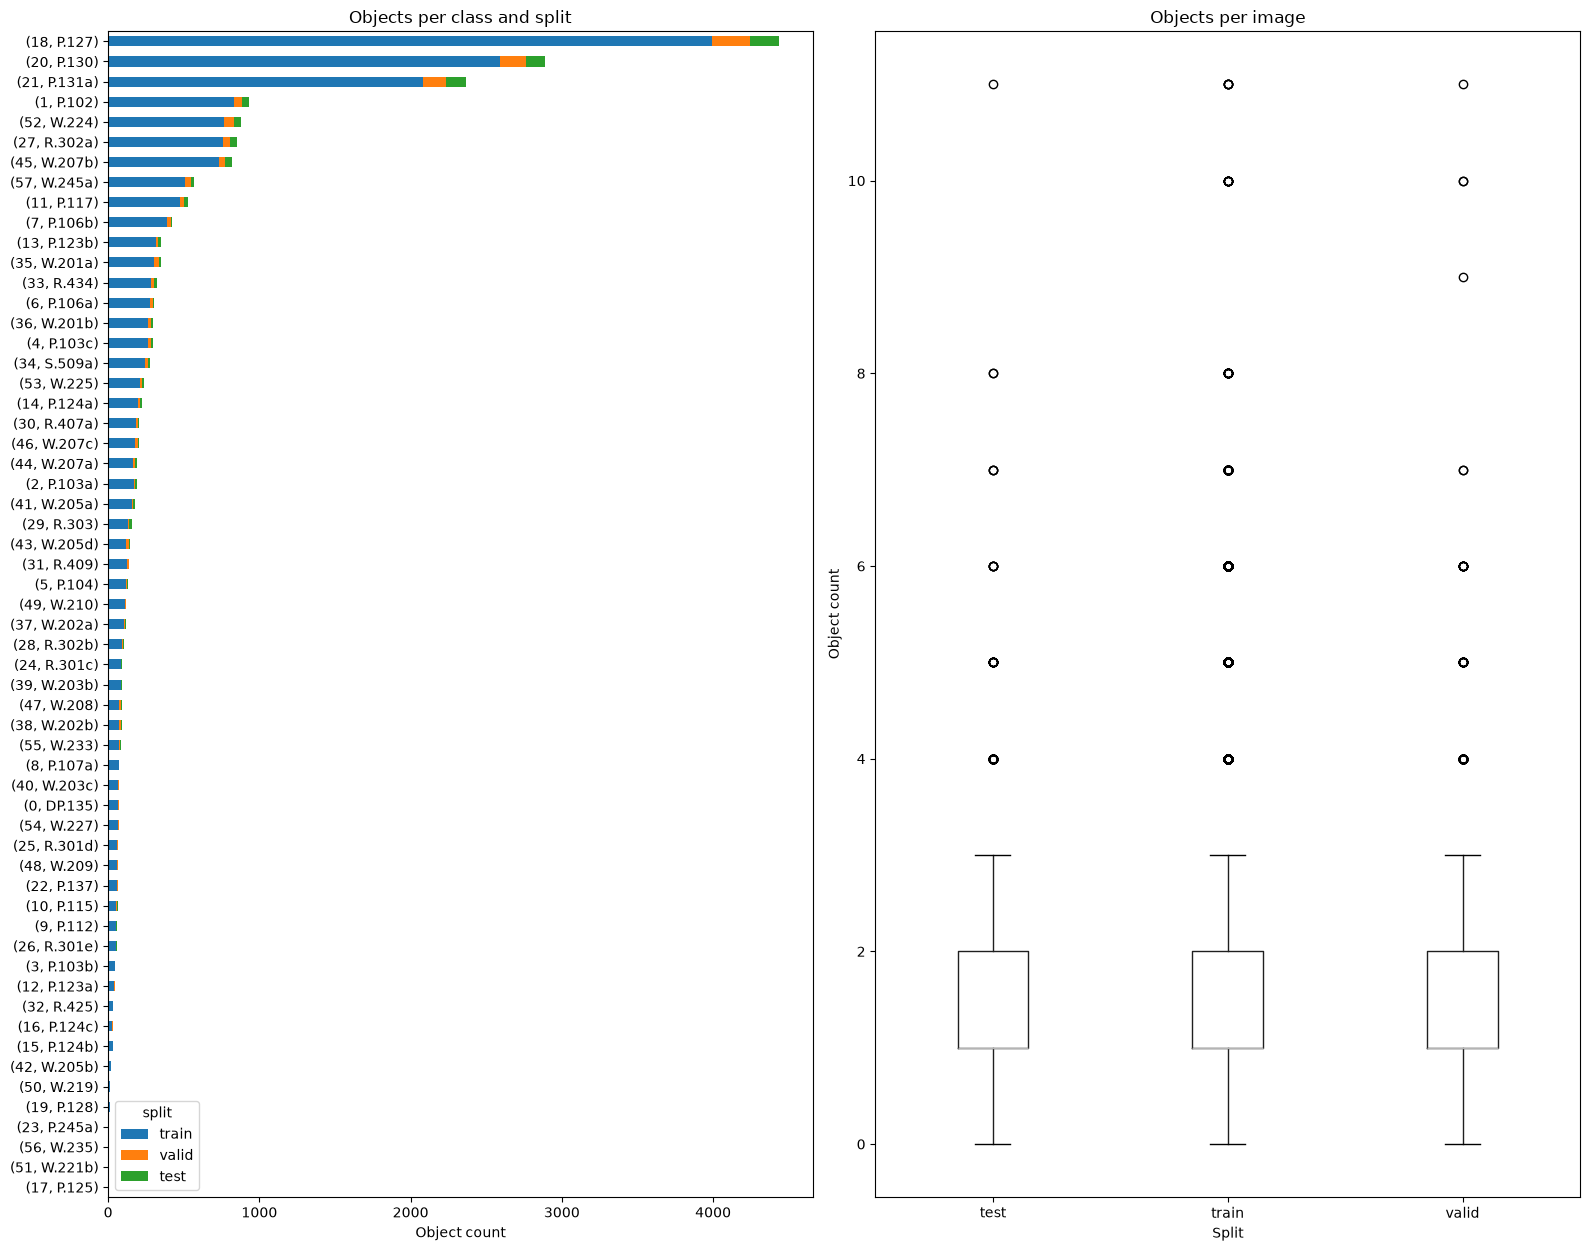

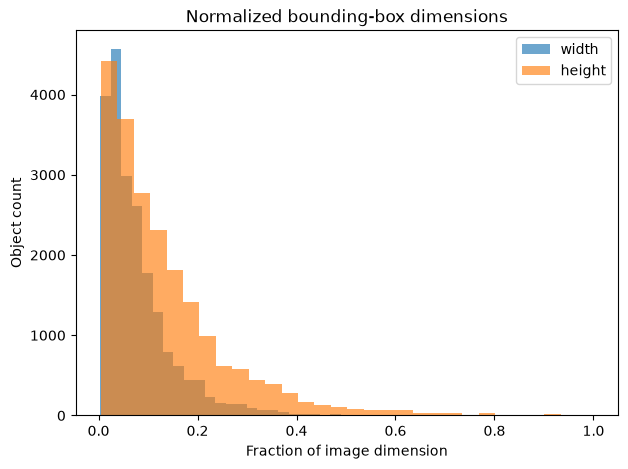

In [5]:
if not annotations.empty:
    class_plot = class_counts.sort_values('total', ascending=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(class_plot) * 0.22)))
    class_plot[list(SPLIT_NAMES)].plot(kind='barh', stacked=True, ax=axes[0])
    axes[0].set(title='Objects per class and split', xlabel='Object count', ylabel='')
    per_image.boxplot(column='objects', by='split', ax=axes[1], grid=False)
    axes[1].set(title='Objects per image', xlabel='Split', ylabel='Object count')
    fig.suptitle('')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.hist(annotations['box_width'], bins=30, alpha=0.65, label='width')
    plt.hist(annotations['box_height'], bins=30, alpha=0.65, label='height')
    plt.title('Normalized bounding-box dimensions')
    plt.xlabel('Fraction of image dimension')
    plt.ylabel('Object count')
    plt.legend()
    plt.show()

## Sample images with bounding boxes

Display random readable examples from a selected split. YOLO normalized center-width-height boxes are converted to pixel coordinates for drawing.

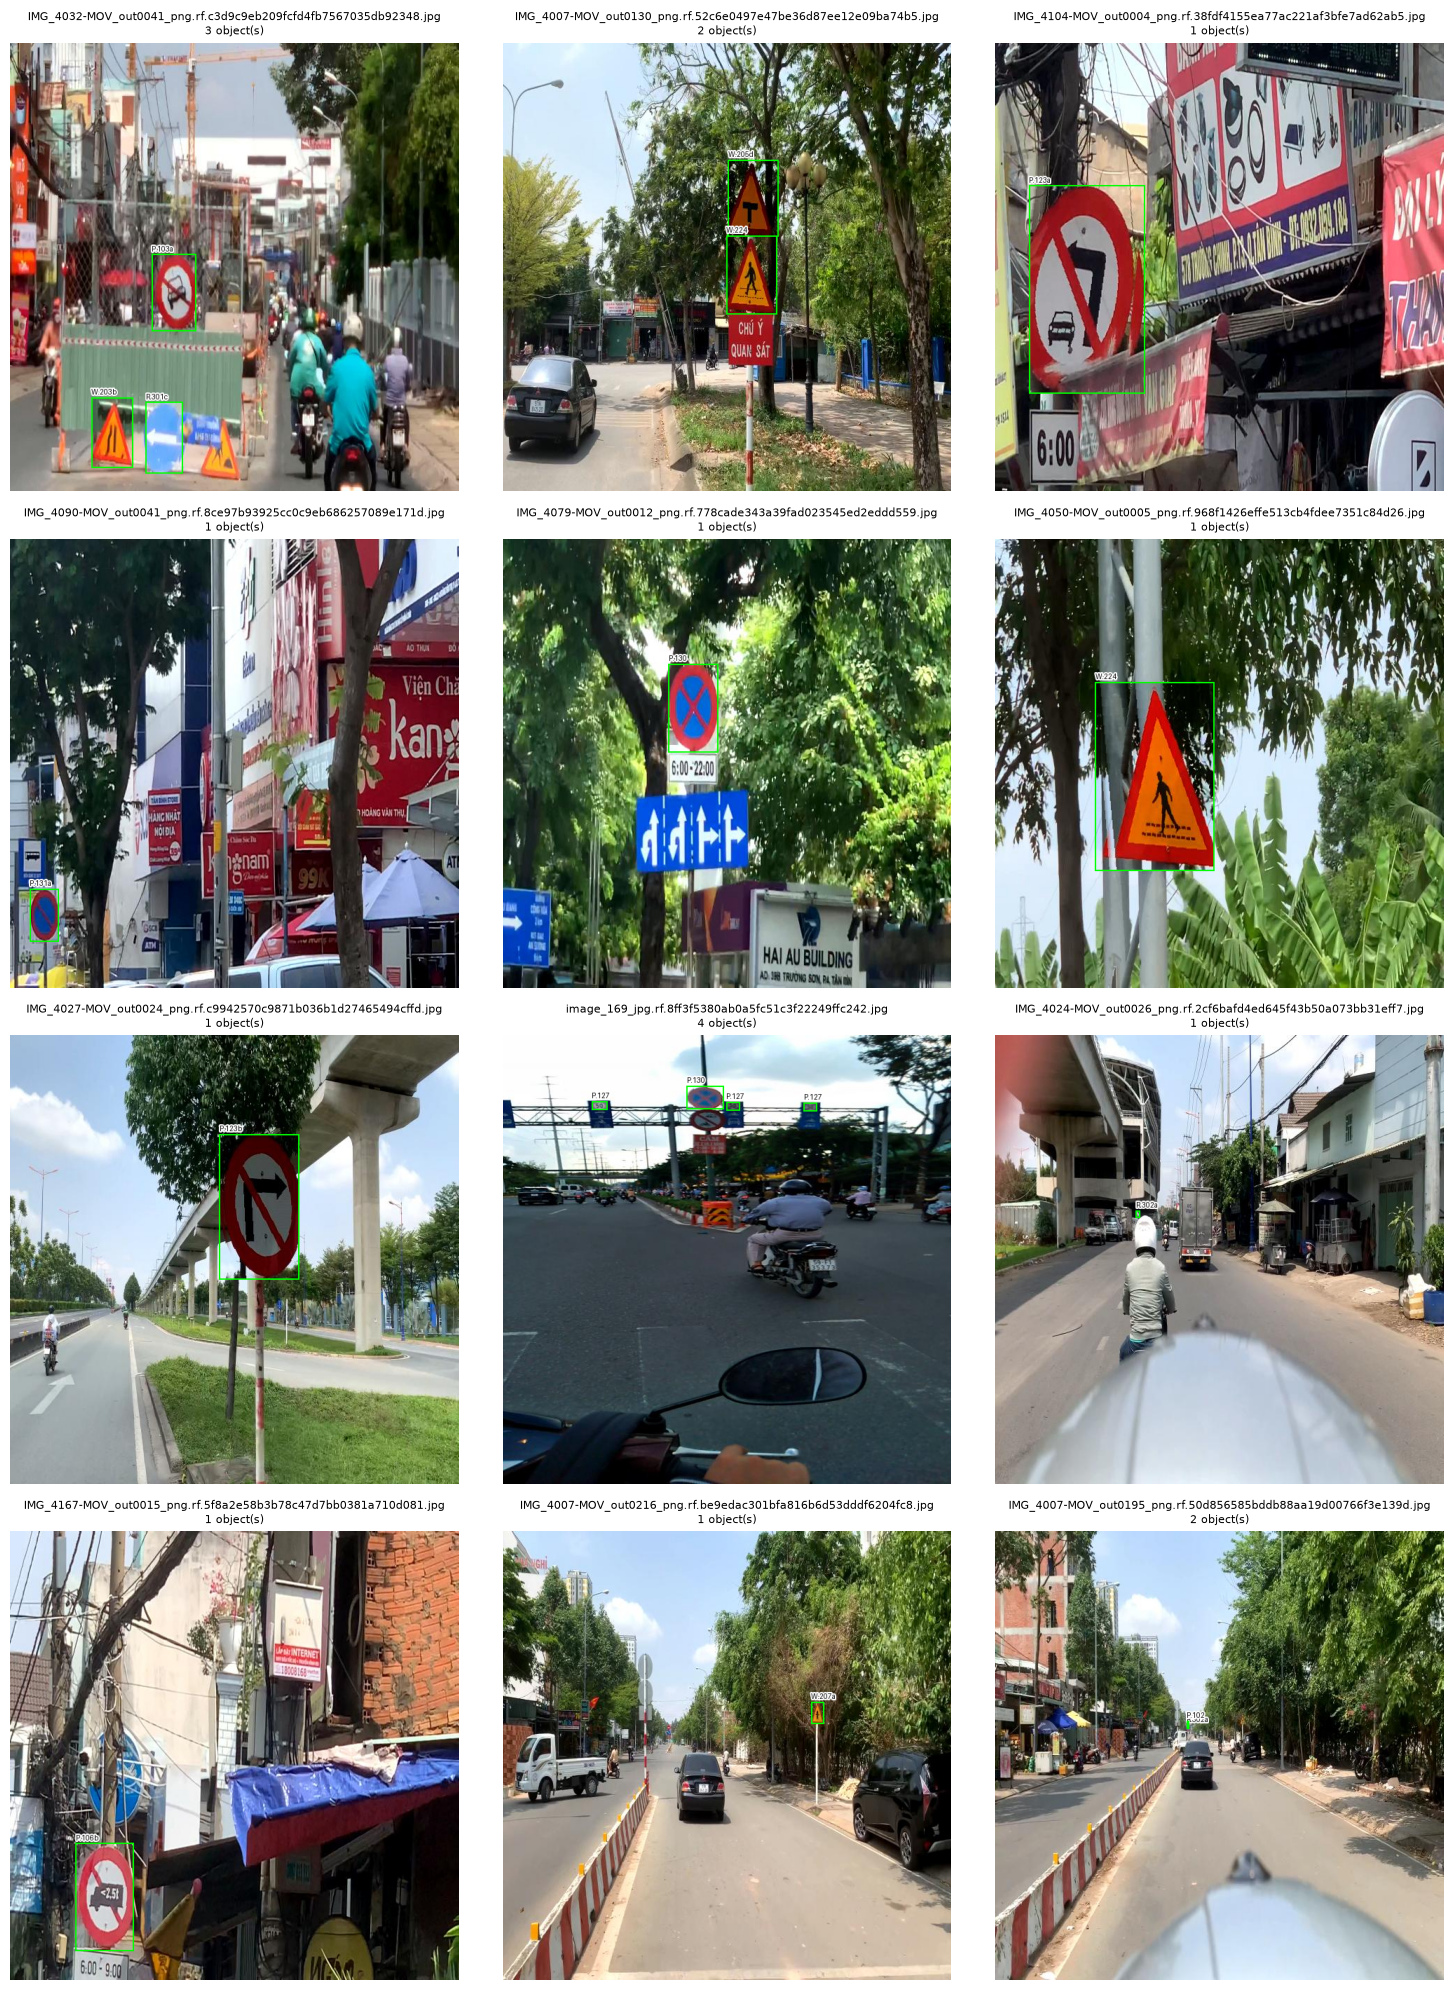

In [6]:
SAMPLE_SPLIT = 'train'  # Change to 'valid' or 'test' as needed.
N_SAMPLES = 12
RANDOM_SEED = 42

sample_candidates = [
    row for row in image_rows
    if row['split'] == SAMPLE_SPLIT and row['read_error'] is None
]
rng = random.Random(RANDOM_SEED)
samples = rng.sample(sample_candidates, min(N_SAMPLES, len(sample_candidates)))
if not samples:
    print(f'No readable images found for split: {SAMPLE_SPLIT}')
else:
    columns = 3
    rows_count = (len(samples) + columns - 1) // columns
    fig, axes = plt.subplots(rows_count, columns, figsize=(15, 5 * rows_count), squeeze=False)
    for ax, sample in zip(axes.flat, samples):
        with Image.open(sample['image']) as source:
            image = source.convert('RGB')
        draw = ImageDraw.Draw(image)
        sample_annotations = annotations[annotations['image'] == sample['image']]
        for _, box in sample_annotations.iterrows():
            x1 = (box.x_center - box.box_width / 2) * image.width
            y1 = (box.y_center - box.box_height / 2) * image.height
            x2 = (box.x_center + box.box_width / 2) * image.width
            y2 = (box.y_center + box.box_height / 2) * image.height
            draw.rectangle((x1, y1, x2, y2), outline='lime', width=max(2, image.width // 320))
            label = str(box.class_name)
            draw.text((x1, max(0, y1 - 14)), label, fill='black', stroke_width=2, stroke_fill='white')
        ax.imshow(image)
        ax.set_title(f"{sample['image'].name}\n{len(sample_annotations)} object(s)", fontsize=8)
        ax.axis('off')
    for ax in axes.flat[len(samples):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()